In [1]:
# Reads in FITS files from the MCT and checks them

In [2]:
from astropy.io import fits
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval


%matplotlib inline

In [3]:
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/up_the_ramp/'
stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407154830/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155057/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155147/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155336/'

In [4]:
def plot_mct_readouts(dir_name, data_cube, slopes, intercepts):
    
    fig, axs = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
    im0 = axs[0].imshow(data_cube[-1, :, :], origin='lower', cmap='gray')
    axs[0].set_xlabel('x (pix)')
    axs[0].set_ylabel('y (pix)')
    axs[0].set_title('Last read in ramp')
    fig.colorbar(im0, ax=axs[0], label='counts')

    im1 = axs[1].imshow(slopes, origin='lower', cmap='gray', norm=LogNorm())
    axs[1].set_xlabel('x (pix)')
    axs[1].set_ylabel('y (pix)')
    axs[1].set_title('Slopes (log color scale)')
    fig.colorbar(im1, ax=axs[1], label='counts/read')

    zscale = ZScaleInterval()
    vmin, vmax = zscale.get_limits(slopes)
    im2 = axs[2].imshow(
        slopes,
        origin='lower',
        cmap='gray',
        vmin=vmin,
        vmax=vmax,
    )
    axs[2].set_xlabel('x (pix)')
    axs[2].set_ylabel('y (pix)')
    axs[2].set_title('Slopes (z color scale)')
    fig.colorbar(im2, ax=axs[2], label='counts/read')

    im3 = axs[3].imshow(intercepts, origin='lower', cmap='gray')
    axs[3].set_xlabel('x (pix)')
    axs[3].set_ylabel('y (pix)')
    axs[3].set_title('Y-intercepts')
    fig.colorbar(im3, ax=axs[3], label='counts')
    plt.suptitle(dir_name)
    #plt.show()
    plt.savefig(dir_name + '.png')
    plt.close()
    print('Plots saved to ' + dir_name + '.png')
    return

In [5]:
file_name_list = glob.glob(stem + '/*.fits')
size_window = 2048
print(file_name_list)
first_idx_to_fit = 20
file_name_list = sorted(file_name_list) # the files to use for the fitting

# read in each 2D frame into a 3D cube
# read in a test frame to get the shape of the data
data_test = fits.open(file_name_list[0])[0].data
# make a 3D cube of the data
data_cube = np.zeros((len(file_name_list), data_test.shape[0], data_test.shape[1]))
for i, file_name in enumerate(file_name_list):
    hdul = fits.open(file_name)
    data_cube[i, :, :] = hdul[0].data

# make a linear fit to the pixels for each pixel
idx_frames = np.arange(len(file_name_list))
x = np.asarray(idx_frames)

# subtract per-frame median from each 64-pixel readout column
data_cube_corr = data_cube[:, :size_window, :size_window].copy()
readout_width = 64
for col_start in range(0, size_window, readout_width):
    col_end = min(col_start + readout_width, size_window)
    readout = data_cube_corr[:, :, col_start:col_end]
    readout_median = np.median(readout, axis=(1, 2), keepdims=True)
    data_cube_corr[:, :, col_start:col_end] = readout - readout_median

# drop the first few slices to make the fits
print(data_cube_corr.shape)
data_cube_corr_trunc = data_cube_corr[first_idx_to_fit:,:,:]
print(data_cube_corr_trunc.shape)

x_trunc = x[first_idx_to_fit:]
Y2 = data_cube_corr_trunc.reshape(len(x_trunc), -1)
A = np.vstack([x_trunc, np.ones_like(x_trunc)]).T
coeffs, _, _, _ = np.linalg.lstsq(A, Y2, rcond=None)
slopes = coeffs[0].reshape(size_window, size_window)
intercepts = coeffs[1].reshape(size_window, size_window)

print('slopes')
print(slopes)
print('intercepts')
print(intercepts)

_ = plot_mct_readouts(dir_name=stem, data_cube=data_cube, slopes=slopes, intercepts=intercepts)

['/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N49.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N08.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N24.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N32.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N45.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckhart_20260617/20260617130641/H2RG_R01_M01_N12.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/data/mct_readouts/eckha

In [6]:
slopes.shape

(2048, 2048)

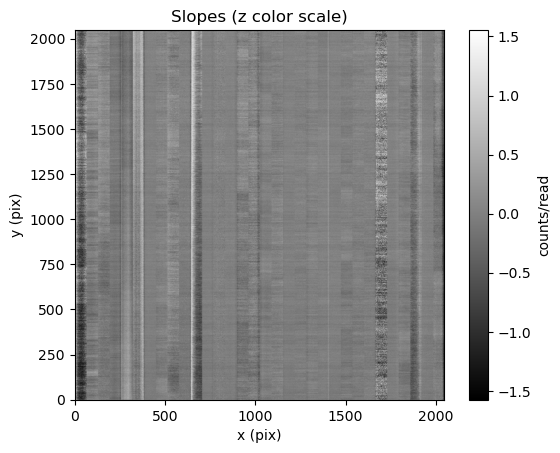

In [7]:
plt.clf()
plt.imshow(slopes, origin='lower')
plt.colorbar(label='counts/read')
plt.title('Up-the-ramp slopes')
plt.xlabel('x (pix)')
plt.ylabel('y (pix)')
#plt.show()
# Save the slopes array as a FITS file
hdu = fits.PrimaryHDU(slopes)
hdu.writeto('/Users/eckhartspalding/Downloads/slopes.fits', overwrite=True)

# make a second plot, of a random sample of pixel responses and the fitted slopes
plt.savefig('slopes.png')
plt.close()

# make another plot, with z-scale colorscale

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(slopes)
im2 = plt.imshow(
    slopes,
    origin='lower',
    cmap='gray',
    vmin=vmin,
    vmax=vmax,
)
plt.xlabel('x (pix)')
plt.ylabel('y (pix)')
plt.title('Slopes (z color scale)')
plt.colorbar(im2, label='counts/read')
plt.savefig('/Users/eckhartspalding/Downloads/slopes_zscale.png')


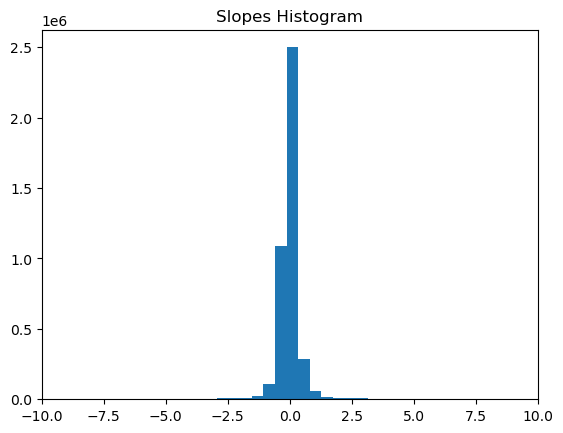

In [8]:
plt.clf()
plt.hist(slopes.flatten(), bins = 800)
plt.xlim([-10, 10])
plt.title('Slopes Histogram')
plt.savefig('/Users/eckhartspalding/Downloads/slopes_histogram.png')

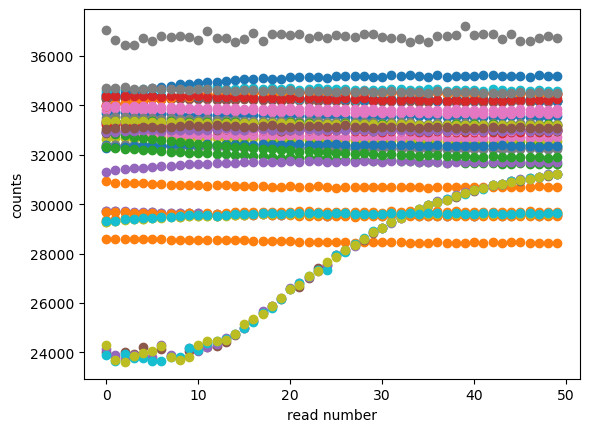

In [9]:
# plot five pixel responses, with N_, M_, randomly chosen from within the cube:

# number of slices
n_slices = len(data_cube[:,0,0])

for i in range(n_slices):
    N_ = np.random.randint(0, size_window)
    M_ = np.random.randint(0, size_window)
    plt.scatter(x, data_cube[:,N_,M_])
plt.xlabel('read number')
plt.ylabel('counts')
plt.savefig('/Users/eckhartspalding/Downloads/pixel_responses.png')  

In [10]:
# for each readout column 64 pixels wide, subtract the median
    
# normalize each 64-pixel readout column by its own median

slopes_test = slopes - np.median(slopes, axis=0)

channel_width = 64
for i in range(0,32):
    idx_0 = i*channel_width
    idx_1 = (i+1)*channel_width
    slopes_test[:,idx_0:idx_1] = slopes_test[:,idx_0:idx_1] - np.median(slopes_test[:,idx_0:idx_1])

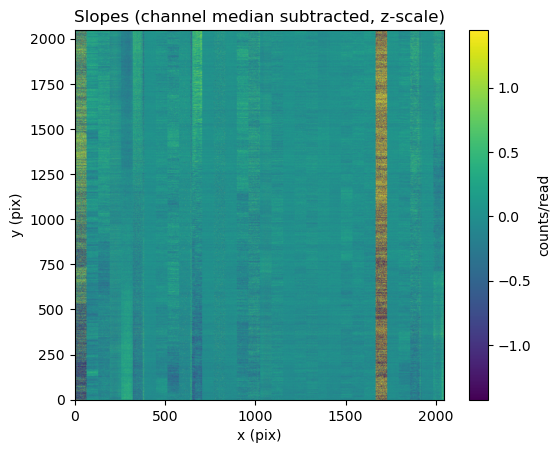

<Figure size 640x480 with 0 Axes>

In [11]:
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(slopes_test)
plt.imshow(slopes_test, origin='lower', vmin=vmin, vmax=vmax)
plt.colorbar(label='counts/read')
plt.title('Slopes (channel median subtracted, z-scale)')
plt.xlabel('x (pix)')
plt.ylabel('y (pix)')
plt.show()

plt.savefig('slopes_test.png')

hdu = fits.PrimaryHDU(slopes_test)
hdu.writeto('/Users/eckhartspalding/Downloads/slopes_test.fits', overwrite=True)


In [12]:
# take one file, see pixel reponse

file_name_list = glob.glob(stem + sub + '/*.fits')

NameError: name 'sub' is not defined